# Módulo 01 — Notebook 1: Python para Machine Learning

## Objetivos desta aula

Ao final deste notebook, você será capaz de:
- Usar **NumPy** para operações matemáticas eficientes com arrays
- Manipular dados tabulares com **Pandas**
- Criar visualizações informativas com **Matplotlib** e **Seaborn**
- Entender como essas bibliotecas formam a base de qualquer projeto de ML

---

## Por que essas bibliotecas?

Em Machine Learning, trabalhamos com **dados em grande escala** — matrizes de pixels, vetores de áudio, tabelas com milhares de linhas. Python puro seria lento demais para isso.

As bibliotecas abaixo são escritas em C/C++ internamente, mas têm interface Python simples:

| Biblioteca | Papel principal |
|---|---|
| **NumPy** | Operações matemáticas com arrays N-dimensionais |
| **Pandas** | Manipulação de dados tabulares (DataFrames) |
| **Matplotlib** | Visualização de dados (gráficos) |
| **Seaborn** | Visualizações estatísticas de alto nível |


In [1]:
# Verificando versões das bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print(f'NumPy:      {np.__version__}')
print(f'Pandas:     {pd.__version__}')
print(f'Matplotlib: {plt.matplotlib.__version__}')
print(f'Seaborn:    {sns.__version__}')

NumPy:      2.4.2
Pandas:     3.0.2
Matplotlib: 3.10.8
Seaborn:    0.13.2


---

## Parte 1: NumPy — A Base do ML em Python

### O que é um array NumPy?

Um `ndarray` (N-dimensional array) é a estrutura central do NumPy. Pense nele como uma grade de valores do **mesmo tipo** (diferente de listas Python que aceitam tipos mistos).

```
Lista Python:  [1, 'dois', 3.0]   → tipos mistos, lentos
Array NumPy:   [1, 2, 3]          → mesmo tipo, muito rápidos
```


##### 1.1 - Criando Arrays

In [2]:
# A partir de uma lista Python
a = np.array([1, 2, 3, 4, 5])
print('Vetor:', a)
print('Tipo:', a.dtype)
print('Shape:', a.shape)   # (5,) = 5 elementos numa dimensão
print('Ndim:', a.ndim)

# # Array 2D (matriz)
M = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print('\nMatriz 3x3:\n', M)
print('Tipo:', M.dtype)
print('Shape:', M.shape)    # (3, 3) = 3 linhas, 3 colunas
print('Ndim:', M.ndim)      # número de dimensões

Vetor: [1 2 3 4 5]
Tipo: int64
Shape: (5,)
Ndim: 1

Matriz 3x3:
 [[1 2 3]
 [4 5 6]
 [7 8 9]]
Tipo: int64
Shape: (3, 3)
Ndim: 2


##### 1.2 - Funções para criar arrays especiais

In [3]:
print('--- Zeros ---')
print(np.zeros((3, 4)))        # 3 linhas, 4 colunas de zeros

print('\n--- Uns ---')
print(np.ones((2, 3)))         # 2x3 de 1's

print('\n--- Identidade ---')
print(np.eye(3))               # matriz identidade 3x3

print('\n--- Range ---')
print(np.arange(0, 10, 2))     # de 0 a 10 (exclusive), passo 2

print('\n--- Espaço linear ---')
print(np.linspace(0, 1, 5))    # 5 pontos igualmente espaçados entre 0 e 1

print('\n--- Aleatórios (com seed para reprodutibilidade) ---')
rng = np.random.default_rng(seed=42) # testar mudança sem seed
print(rng.random((3, 3)))      # valores uniformes [0, 1)

--- Zeros ---
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

--- Uns ---
[[1. 1. 1.]
 [1. 1. 1.]]

--- Identidade ---
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

--- Range ---
[0 2 4 6 8]

--- Espaço linear ---
[0.   0.25 0.5  0.75 1.  ]

--- Aleatórios (com seed para reprodutibilidade) ---
[[0.77395605 0.43887844 0.85859792]
 [0.69736803 0.09417735 0.97562235]
 [0.7611397  0.78606431 0.12811363]]


##### 1.3 - Indexação e Slicing (fatiamento)

In [4]:
M = np.array([[10, 20, 30],
              [40, 50, 60],
              [70, 80, 90]])

# Elemento individual: M[linha, coluna]
print('Elemento [1,2]:', M[1, 2])

# Linha inteira
print('Linha 0:', M[0, :])          # [10, 20, 30]
print('Linha 0 (atalho):', M[0])    # [10, 20, 30] (mesmo resultado)

# Coluna inteira
print('Coluna 1:', M[:, 1])         # [20, 50, 80]

# Submatriz
print('Submatriz [0:2, 1:3]:\n', M[0:2, 1:3])  # linhas 0-1, colunas 1-2

# Indexação booleana (muito importante e útil)
print('\nElementos > 50:', M[M > 50])

# Elementos limites (últimos)
print('Última linha:', M[-1])
print('Última coluna:', M[:, -1])
print('Submatriz antes das últimas coordenadas:\n', M[:-1, :-1]) 

Elemento [1,2]: 60
Linha 0: [10 20 30]
Linha 0 (atalho): [10 20 30]
Coluna 1: [20 50 80]
Submatriz [0:2, 1:3]:
 [[20 30]
 [50 60]]

Elementos > 50: [60 70 80 90]
Última linha: [70 80 90]
Última coluna: [30 60 90]
Submatriz antes das últimas coordenadas:
 [[10 20]
 [40 50]]


##### 1.4 - Operações Matemáticas: a magia do NumPy

In [5]:
a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

# Operações element-wise (automáticas, sem loop!)
print('a + b:', a + b)
print('a * b:', a * b)
print('a ** 2:', a ** 2)
print('b / a:', b / a)

# Operações com escalar
print('a + 100:', a + 100)   # Broadcasting: 100 é aplicado a cada elemento

# Funções universais (ufuncs)
print('\nMédia de a:', np.mean(a))
print('Desvio padrão de a:', np.std(a))
print('Soma de a:', np.sum(a))
print('Max de b:', np.max(b))
print('Índice do max:', np.argmax(b))

a + b: [11 22 33 44]
a * b: [ 10  40  90 160]
a ** 2: [ 1  4  9 16]
b / a: [10. 10. 10. 10.]
a + 100: [101 102 103 104]

Média de a: 2.5
Desvio padrão de a: 1.118033988749895
Soma de a: 10
Max de b: 40
Índice do max: 3


##### 1.5 - Broadcasting: operações entre arrays de shapes diferentes

In [6]:
# Broadcasting permite operar arrays com shapes compatíveis
# Regra: o shape menor é 'expandido' para se alinhar ao maior

M = np.array([[1, 2, 3],
              [4, 5, 6]])
v = np.array([10, 20, 30])   # vetor com 3 elementos (1 linha)

# NumPy 'entende' que v deve ser aplicado a cada linha de M
#  em condições normais de álgebra linear, a soma de matrizes de tamanhos diferentes não é possível.
print('M + v:\n', M + v)

# Prático em ML: normalizar cada coluna de um dataset
dataset = rng.random((5, 3))
print('\nDataset original (Z-score):')
print(dataset.round(2))

media = dataset.mean(axis=0)    # média de cada coluna
std   = dataset.std(axis=0)     # desvio padrão de cada coluna
print('Média das colunas:', media.round(10))

normalizado = (dataset - media) / std
print('\nDataset normalizado (Z-score):')
print(normalizado.round(2))
print('Média das colunas:', normalizado.mean(axis=0).round(10))  # ≈ 0

M + v:
 [[11 22 33]
 [14 25 36]]

Dataset original (Z-score):
[[0.45 0.37 0.93]
 [0.64 0.82 0.44]
 [0.23 0.55 0.06]
 [0.83 0.63 0.76]
 [0.35 0.97 0.89]]
Média das colunas: [0.50072938 0.67010137 0.61704106]

Dataset normalizado (Z-score):
[[-0.24 -1.43  0.95]
 [ 0.67  0.73 -0.53]
 [-1.29 -0.55 -1.7 ]
 [ 1.54 -0.18  0.43]
 [-0.69  1.44  0.85]]
Média das colunas: [ 0.  0. -0.]


##### 1.6 - Álgebra Linear: essencial para ML

In [7]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print('Matriz A:\n', A)
print('\nMatriz B:\n', B)

# Produto matricial (operação fundamental em redes neurais)
print('\nA @ B (produto matricial):\n', A @ B)
# Equivalente a: np.matmul(A, B)

# Transposta
print('\nTransposta de A:\n', A.T)

# Determinante e inversa
print('\nDeterminante de A:', np.linalg.det(A).round(4))
print('Inversa de A:\n', np.linalg.inv(A).round(4)) # matriz que multiplicada por A dá a identidade

print('\nInversa de A * A = I:\n', np.linalg.inv(A).round(4) @ A)

# Autovalores e autovetores (e.g., usados em PCA - Principal Component Analysis)
eigenvalues, eigenvectors = np.linalg.eig(A)
print('\nAutovalores:', eigenvalues)
print('Autovetores:\n', eigenvectors)

Matriz A:
 [[1 2]
 [3 4]]

Matriz B:
 [[5 6]
 [7 8]]

A @ B (produto matricial):
 [[19 22]
 [43 50]]

Transposta de A:
 [[1 3]
 [2 4]]

Determinante de A: -2.0
Inversa de A:
 [[-2.   1. ]
 [ 1.5 -0.5]]

Inversa de A * A = I:
 [[1. 0.]
 [0. 1.]]

Autovalores: [-0.37228132  5.37228132]
Autovetores:
 [[-0.82456484 -0.41597356]
 [ 0.56576746 -0.90937671]]


---

## Parte 2: Pandas — Dados Tabulares

O **Pandas** é a biblioteca padrão para manipulação de dados tabulares em Python. Pense nele como um Excel programável.

As duas estruturas principais são:
- **Series**: uma coluna (array 1D com índice)
- **DataFrame**: uma tabela (várias Series lado a lado)


##### 2.1 - Criando DataFrames

In [8]:
# A partir de um dicionário
dados = {
    'participante': ['Alice', 'Bob', 'Carol', 'David', 'Eva'],
    'idade': [25, 32, 28, 45, 37],
    'genero': ['F', 'M', 'F', 'M', 'F'],
    'tom_medio_hz': [215.3, 120.8, 198.5, 105.2, 220.1],
    'variabilidade_hz': [18.2, 9.5, 22.1, 7.8, 25.3]
}

df = pd.DataFrame(dados)
print('DataFrame criado:')
df

DataFrame criado:


,participante,idade,genero,tom_medio_hz,variabilidade_hz
0,Alice,25,F,215.3,18.2
1,Bob,32,M,120.8,9.5
2,Carol,28,F,198.5,22.1
3,David,45,M,105.2,7.8
4,Eva,37,F,220.1,25.3


##### 2.2 - Explorando o DataFrame

In [9]:
print('============== Informações básicas ==============')
print(df.info())

print('\n=========== Estatísticas descritivas ===========')
print(df.describe())

============== Informações básicas ==============
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   participante      5 non-null      str    
 1   idade             5 non-null      int64  
 2   genero            5 non-null      str    
 3   tom_medio_hz      5 non-null      float64
 4   variabilidade_hz  5 non-null      float64
dtypes: float64(2), int64(1), str(2)
memory usage: 358.0 bytes
None

=========== Estatísticas descritivas ===========
           idade  tom_medio_hz  variabilidade_hz
count   5.000000      5.000000          5.000000
mean   33.400000    171.980000         16.580000
std     7.893035     54.713865          7.686807
min    25.000000    105.200000          7.800000
25%    28.000000    120.800000          9.500000
50%    32.000000    198.500000         18.200000
75%    37.000000    215.300000         22.100000
max    45.000000    22

##### 2.3 - Seleção e Filtragem

In [10]:
# Selecionar uma coluna → Series
print('Coluna tom_medio_hz:')
print(df['tom_medio_hz'])

# Selecionar múltiplas colunas → DataFrame
print('\nColunas selecionadas:')
print(df[['participante', 'tom_medio_hz', 'variabilidade_hz']])

# Filtrar linhas por condição
print('\nParticipantes do gênero F:')
print(df[df['genero'] == 'F'])

# Múltiplas condições
print('\nFemininoS com tom > 200 Hz:')
print(df[(df['genero'] == 'F') & (df['tom_medio_hz'] > 200)])

Coluna tom_medio_hz:
0    215.3
1    120.8
2    198.5
3    105.2
4    220.1
Name: tom_medio_hz, dtype: float64

Colunas selecionadas:
  participante  tom_medio_hz  variabilidade_hz
0        Alice         215.3              18.2
1          Bob         120.8               9.5
2        Carol         198.5              22.1
3        David         105.2               7.8
4          Eva         220.1              25.3

Participantes do gênero F:
  participante  idade genero  tom_medio_hz  variabilidade_hz
0        Alice     25      F         215.3              18.2
2        Carol     28      F         198.5              22.1
4          Eva     37      F         220.1              25.3

FemininoS com tom > 200 Hz:
  participante  idade genero  tom_medio_hz  variabilidade_hz
0        Alice     25      F         215.3              18.2
4          Eva     37      F         220.1              25.3


##### 2.4 - Operações e Transformações

In [11]:
# Criar nova coluna
df['tom_normalizado'] = (df['tom_medio_hz'] - df['tom_medio_hz'].mean()) / df['tom_medio_hz'].std()
print('Com coluna normalizada:')
print(df[['participante', 'tom_medio_hz', 'tom_normalizado']].round(3))

# Agrupamento (groupby) — muito usado em análise de dados
print('\nMédia por gênero:')
print(df.groupby('genero')[['tom_medio_hz', 'variabilidade_hz']].mean().round(2))

# Ordenar
print('\nOrdenado por tom (decrescente):')
print(df.sort_values('tom_medio_hz', ascending=False)[['participante', 'tom_medio_hz']])

Com coluna normalizada:
  participante  tom_medio_hz  tom_normalizado
0        Alice         215.3            0.792
1          Bob         120.8           -0.935
2        Carol         198.5            0.485
3        David         105.2           -1.221
4          Eva         220.1            0.879

Média por gênero:
        tom_medio_hz  variabilidade_hz
genero                                
F              211.3             21.87
M              113.0              8.65

Ordenado por tom (decrescente):
  participante  tom_medio_hz
4          Eva         220.1
0        Alice         215.3
2        Carol         198.5
1          Bob         120.8
3        David         105.2


##### 2.5 - Lidando com dados ausentes

In [12]:
# Criando DataFrame com valores ausentes
df_com_falhas = pd.DataFrame({
    'participante': ['P1', 'P2', 'P3', 'P4', 'P5'],
    'tom_hz': [210.0, None, 185.0, np.nan, 230.0], #np.nan = valor nulo
    'ruido_db': [45.0, 52.0, None, 48.0, 51.0]
})

print('DataFrame com falhas:')
print(df_com_falhas)

print('\nValores nulos por coluna:')
print(df_com_falhas.isnull().sum())

# Estratégia 1: Remover linhas com qualquer valor ausente
print('\nApós dropna():')
print(df_com_falhas.dropna(axis=0))

# Estratégia 2: Preencher com a média (imputação)
df_imputado = df_com_falhas.copy()
df_imputado['tom_hz'] = df_imputado['tom_hz'].fillna(df_imputado['tom_hz'].mean())
df_imputado['ruido_db'] = df_imputado['ruido_db'].fillna(df_imputado['ruido_db'].median())
print('\nApós imputação:')
print(df_imputado)

DataFrame com falhas:
  participante  tom_hz  ruido_db
0           P1   210.0      45.0
1           P2     NaN      52.0
2           P3   185.0       NaN
3           P4     NaN      48.0
4           P5   230.0      51.0

Valores nulos por coluna:
participante    0
tom_hz          2
ruido_db        1
dtype: int64

Após dropna():
  participante  tom_hz  ruido_db
0           P1   210.0      45.0
4           P5   230.0      51.0

Após imputação:
  participante      tom_hz  ruido_db
0           P1  210.000000      45.0
1           P2  208.333333      52.0
2           P3  185.000000      49.5
3           P4  208.333333      48.0
4           P5  230.000000      51.0


---

## Parte 3: Matplotlib e Seaborn — Visualização

Visualizar dados é fundamental em ML. Ajuda a:
- Entender distribuições
- Detectar outliers
- Comunicar resultados
- Diagnosticar problemas nos modelos


In [13]:
# Configurações estéticas globais
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('Configurações de visualização aplicadas.')

Configurações de visualização aplicadas.


##### 3.1 - Gráfico de linha: evolução temporal

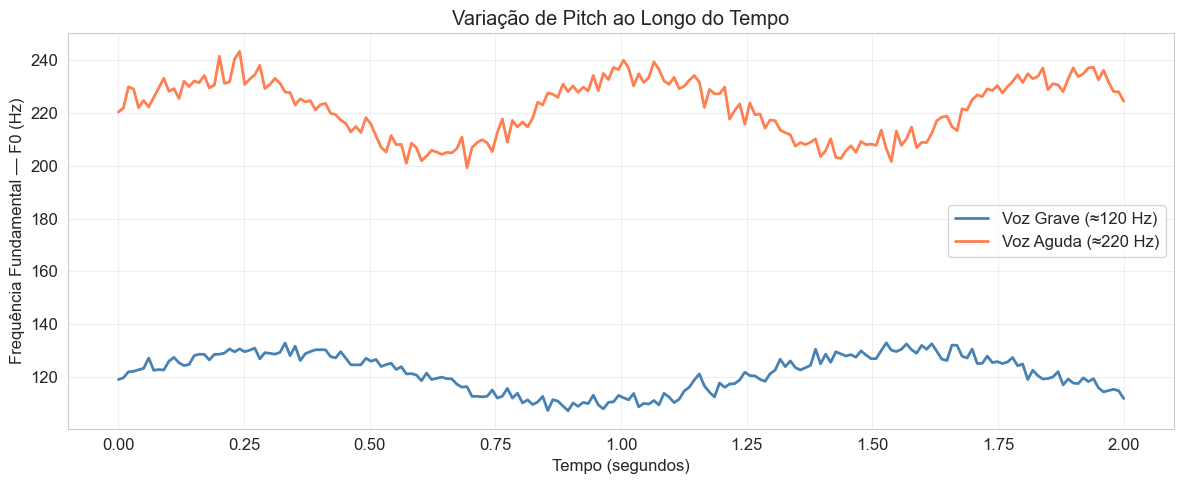

In [14]:
t = np.linspace(0, 2, 200)  # 200 pontos em 2 segundos

# Simulando duas vozes: uma mais grave, outra mais aguda
pitch_grave = 120 + 10 * np.sin(2 * np.pi * 0.8 * t) + rng.normal(0, 2, len(t))
pitch_agudo = 220 + 15 * np.sin(2 * np.pi * 1.2 * t) + rng.normal(0, 3, len(t))

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(t, pitch_grave, label='Voz Grave (≈120 Hz)', color='steelblue', linewidth=2)
ax.plot(t, pitch_agudo, label='Voz Aguda (≈220 Hz)', color='coral', linewidth=2)

ax.set_xlabel('Tempo (segundos)')
ax.set_ylabel('Frequência Fundamental — F0 (Hz)')
ax.set_title('Variação de Pitch ao Longo do Tempo')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### 3.2 - Histograma e boxplot: distribuições

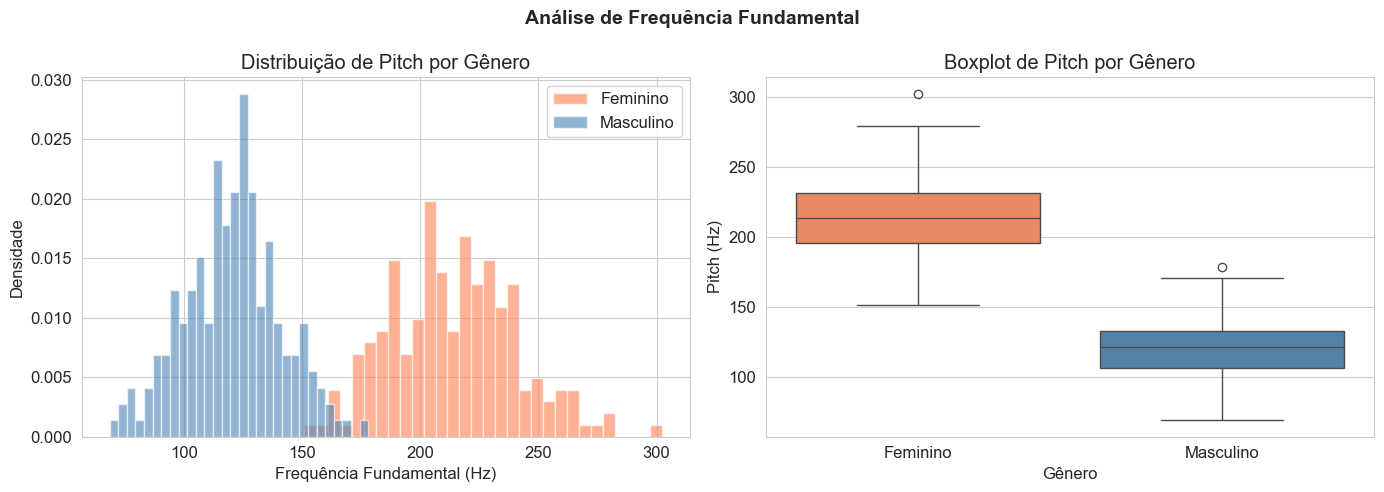

In [15]:
# Gerando dados simulados de pitch para dois grupos
rng = np.random.default_rng(42)
pitch_feminino = rng.normal(215, 30, 200)   # média 215 Hz
pitch_masculino = rng.normal(120, 20, 200)  # média 120 Hz

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(pitch_feminino, bins=30, alpha=0.6, color='coral',
             label='Feminino', density=True)
axes[0].hist(pitch_masculino, bins=30, alpha=0.6, color='steelblue',
             label='Masculino', density=True)
axes[0].set_xlabel('Frequência Fundamental (Hz)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição de Pitch por Gênero')
axes[0].legend()

# Boxplot
dados_boxplot = pd.DataFrame({
    'Pitch (Hz)': np.concatenate([pitch_feminino, pitch_masculino]),
    'Gênero': ['Feminino'] * 200 + ['Masculino'] * 200
})
sns.boxplot(data=dados_boxplot, x='Gênero', y='Pitch (Hz)',
            palette={'Feminino': 'coral', 'Masculino': 'steelblue'}, hue='Gênero', ax=axes[1])
axes[1].set_title('Boxplot de Pitch por Gênero')

plt.suptitle('Análise de Frequência Fundamental', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 3.3 - Scatter plot: relação entre variáveis

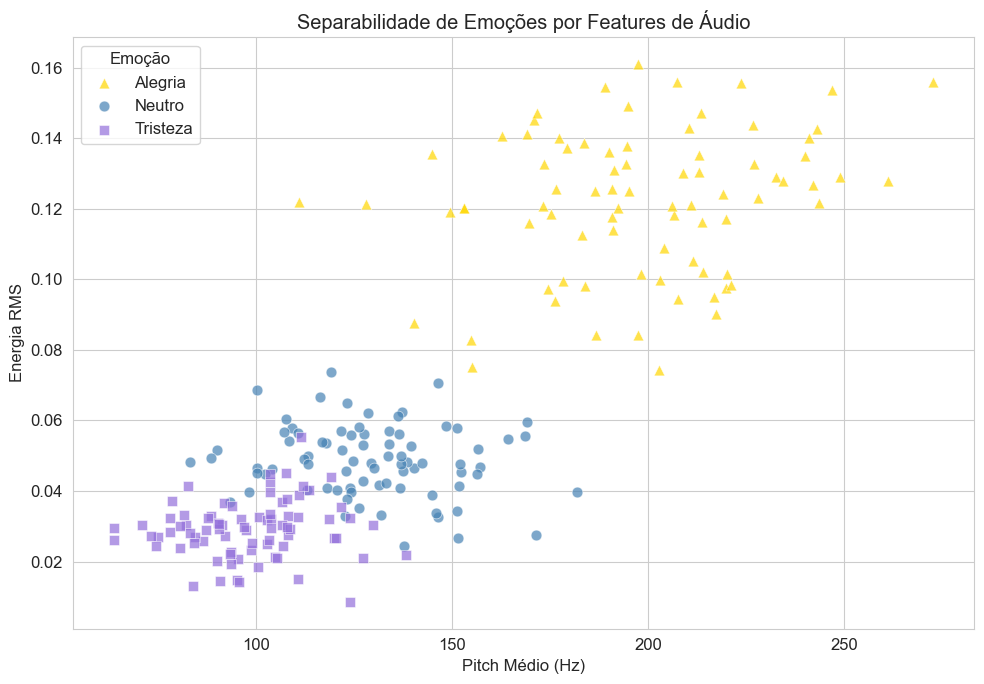

In [16]:
# Simulando features de áudio para 3 emoções
n = 80
dados_emocoes = pd.DataFrame({
    'pitch_medio': np.concatenate([
        rng.normal(130, 20, n),   # neutro
        rng.normal(200, 30, n),   # alegria
        rng.normal(100, 15, n),   # tristeza
    ]),
    'energia_rms': np.concatenate([
        rng.normal(0.05, 0.01, n),
        rng.normal(0.12, 0.02, n),
        rng.normal(0.03, 0.008, n),
    ]),
    'emocao': ['Neutro'] * n + ['Alegria'] * n + ['Tristeza'] * n
})

fig, ax = plt.subplots(figsize=(10, 7))

cores = {'Neutro': 'steelblue', 'Alegria': 'gold', 'Tristeza': 'mediumpurple'}
marcadores = {'Neutro': 'o', 'Alegria': '^', 'Tristeza': 's'}

for emocao, grupo in dados_emocoes.groupby('emocao'):
    ax.scatter(grupo['pitch_medio'], grupo['energia_rms'],
               c=cores[emocao], marker=marcadores[emocao],
               label=emocao, alpha=0.7, s=60, edgecolors='white', linewidth=0.5)

ax.set_xlabel('Pitch Médio (Hz)')
ax.set_ylabel('Energia RMS')
ax.set_title('Separabilidade de Emoções por Features de Áudio')
ax.legend(title='Emoção')
plt.tight_layout()
plt.show()

💡 Vamos refletir: o que podemos observar do gráfico acima?

##### 3.4 - Heatmap de correlação: relacionamentos entre features

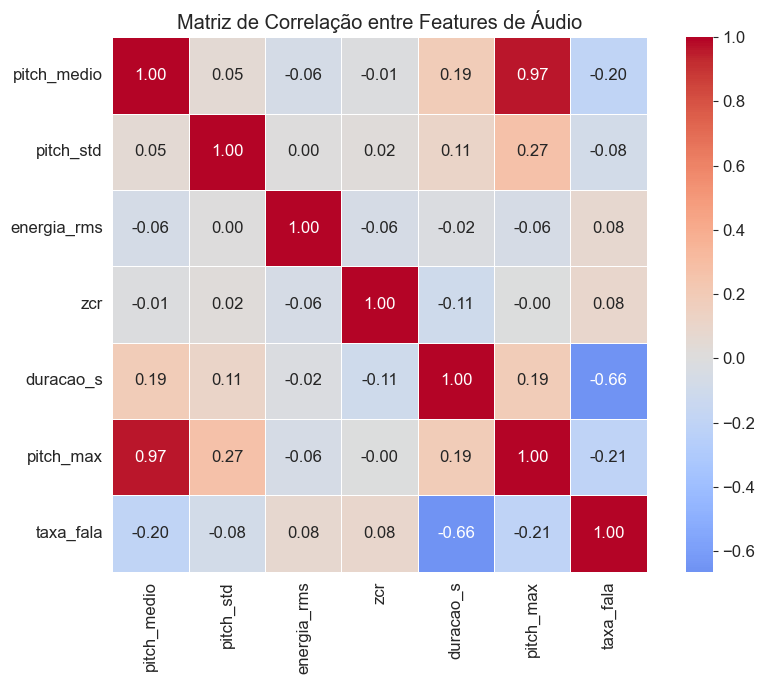

In [17]:
# Dataset simulado com várias features de áudio
n_amostras = 150
features = pd.DataFrame({
    'pitch_medio':  rng.normal(160, 50, n_amostras),
    'pitch_std':    rng.normal(20, 8, n_amostras),
    'energia_rms':  rng.normal(0.07, 0.03, n_amostras),
    'zcr':          rng.normal(0.05, 0.02, n_amostras),
    'duracao_s':    rng.normal(3.0, 1.0, n_amostras),
})

# Adicionando correlações artificiais para o exemplo
features['pitch_max'] = features['pitch_medio'] + features['pitch_std'] * rng.normal(1.5, 0.3, n_amostras)
features['taxa_fala'] = 1 / features['duracao_s'] + rng.normal(0, 0.05, n_amostras)

correlacao = features.corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Matriz de Correlação entre Features de Áudio')
plt.tight_layout()
plt.show()

---

## Hora de praticar!

### Exercício 1 — NumPy
Dado o array `x = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])`, calcule:

a) A média e o desvio padrão  
b) O valor normalizado (Z-score) de cada elemento  
c) Quantos elementos estão acima da média 

In [18]:
# === ESPAÇO PARA RESOLVER OS EXERCÍCIOS ===

# Exercício 1
x = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3])

# Seu código aqui...

### Exercício 2 — Pandas
Crie um DataFrame com dados de 10 gravações de voz (gênero, idade, pitch médio e duração). Em seguida:

a) Calcule o pitch médio por gênero  
b) Filtre gravações com duração > 5 segundos  
c) Adicione uma coluna de categoria de pitch: 'grave' (< 150 Hz), 'médio' (150-180 Hz), 'agudo' (> 180 Hz)  


In [19]:
# === ESPAÇO PARA RESOLVER OS EXERCÍCIOS ===

# Exercício 2
# Seu código aqui...

### Exercício 3 — Visualização
Usando os dados do Exercício 2, crie:

a) Um boxplot de pitch separado por gênero  
b) Um scatter plot de pitch × duração, com cores por categoria de pitch  

In [20]:
# === ESPAÇO PARA RESOLVER OS EXERCÍCIOS ===

# Exercício 3
# Seu código aqui...

---

## Resumo

| Conceito | Biblioteca | O que aprendemos |
|---|---|---|
| Arrays N-dim | NumPy | Criação, indexação, operações vetorizadas, broadcasting |
| Álgebra Linear | NumPy | Produto matricial, transposta, autovalores |
| Dados Tabulares | Pandas | DataFrame, filtragem, groupby, valores nulos |
| Gráficos | Matplotlib | Linha, histograma, scatter |
| Visualização Estatística | Seaborn | Boxplot, heatmap de correlação |

**Próximo notebook:** Padrões de Projeto em Machine Learning — aprenderemos a organizar código de ML de forma reutilizável e escalável.
